In [7]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
import matplotlib.pyplot as plt

In [13]:
# Define data directory
DATA_DIR = "../data/ASD_dataset/"

files_generated = []

print("Loading dataset files...\n")

# Load covariates and clinical data
covariates = pd.read_csv(f"{DATA_DIR}ASD_covariates.csv")
print(f"✓ Loaded covariates: {covariates.shape[0]} samples, {covariates.shape[1]} variables")

# Load genotype data
genotypes = pd.read_csv(f"{DATA_DIR}ASD_genotypes.csv")
print(f"✓ Loaded genotypes: {genotypes.shape[0]} samples, {genotypes.shape[1]-1} SNPs")

# Load expression data (two batches)
expression = pd.read_csv(f"{DATA_DIR}ASD_expression.csv")
print(f"✓ Loaded expression: {expression.shape[0]} samples, {expression.shape[1]-1} genes")

# Load annotations
gene_annotations = pd.read_csv(f"{DATA_DIR}ASD_gene_annotations.csv")
snp_annotations = pd.read_csv(f"{DATA_DIR}ASD_snp_annotations.csv")
print(f"✓ Loaded gene annotations: {len(gene_annotations)} genes annotated")
print(f"✓ Loaded SNP annotations: {len(snp_annotations)} SNPs annotated")

# Set sample as index for easier merging
covariates_indexed = covariates.set_index('sample')
genotypes_indexed = genotypes.set_index('sample')
expression_indexed = expression.set_index('sample')

# Verify all indices match
assert (covariates_indexed.index.equals(genotypes_indexed.index)) and (genotypes_indexed.index.equals(expression_indexed.index)), \
    "Sample indices do not match across datasets!"

print("✓ All datasets aligned by sample ID")
print(f"  - Covariates: {covariates_indexed.shape}")
print(f"  - Genotypes: {genotypes_indexed.shape}")
print(f"  - Expression: {expression_indexed.shape}")

print("\n" + "="*80)
print("ALL DATA LOADED SUCCESSFULLY")
print("="*80)



Loading dataset files...

✓ Loaded covariates: 300 samples, 29 variables
✓ Loaded genotypes: 300 samples, 50 SNPs
✓ Loaded expression: 300 samples, 100 genes
✓ Loaded gene annotations: 7 genes annotated
✓ Loaded SNP annotations: 40 SNPs annotated
✓ All datasets aligned by sample ID
  - Covariates: (300, 28)
  - Genotypes: (300, 50)
  - Expression: (300, 100)

ALL DATA LOADED SUCCESSFULLY


# Multi-Omics Factor Analysis (MOFA)

Since MOFA+ is R-based, we'll implement a similar approach using PCA and canonical correlation analysis (CCA).

In [14]:
expression_indexed

,CNTNAP2,MECP2,GRIN2B,SCN2A,NRXN1,PTEN,CHD8,SYNGAP1,ARID1B,SHANK3,...,SLC1A1,BDNF,NGF,NTF3,NTRK1,NTRK2,NTRK3,CREB1,CREB5,RELN
sample,,,,,,,,,,,,,,,,,,,,,
sample_1,14,207,90,1151,33,5,791,397,133,9678,...,365,310,11,2222,65,32,65,3,12352,96
sample_2,20,302,162,1961,63,3,744,445,168,22235,...,523,387,7,2973,113,79,47,5,14764,221
sample_3,17,193,216,1789,39,0,1089,367,142,19490,...,379,396,2,2129,120,72,57,1,10450,204
sample_4,4,106,83,882,9,2,296,166,62,8354,...,186,143,1,1120,72,31,7,0,5597,46
sample_5,3,148,88,1041,9,0,354,260,88,8757,...,157,258,0,1854,94,26,31,3,7790,99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sample_296,5,130,108,1162,30,0,602,221,85,8654,...,203,218,6,1616,54,47,37,1,5811,72
sample_297,16,360,343,2852,46,7,2026,831,289,23401,...,707,526,1,3180,174,100,62,4,18546,282
sample_298,14,237,176,1639,51,1,908,566,156,14097,...,331,362,5,2198,120,50,67,0,14561,230


In [15]:
genotypes_indexed

,snp_1,snp_2,snp_3,snp_4,snp_5,snp_6,snp_7,snp_8,snp_9,snp_10,...,snp_41,snp_42,snp_43,snp_44,snp_45,snp_46,snp_47,snp_48,snp_49,snp_50
sample,,,,,,,,,,,,,,,,,,,,,
sample_1,0,0,0,0,1,0,0,0,2,2,...,0,0,1,0,0,0,0,0,2,1
sample_2,0,0,0,0,0,0,0,0,2,2,...,0,0,0,0,0,0,0,0,0,0
sample_3,0,0,0,0,0,0,0,0,1,2,...,0,0,1,1,1,2,0,1,0,0
sample_4,0,0,0,0,0,0,1,1,0,1,...,0,0,0,1,1,1,0,1,0,2
sample_5,0,0,0,0,0,0,0,1,0,1,...,0,1,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sample_296,0,0,0,0,0,0,0,1,1,1,...,0,1,1,0,0,0,0,0,1,1
sample_297,0,0,0,0,0,1,1,0,1,2,...,1,0,0,0,1,2,0,0,1,1
sample_298,0,0,0,0,0,0,0,1,1,2,...,0,0,0,0,1,1,0,1,1,1


Performing Multi-Omics Factor Analysis

Identified 5 latent factors

Factor-ASD Associations:
  Factor1: r=0.059, p=0.3092
  Factor2: r=0.216, p=0.0002
  Factor3: r=-0.139, p=0.0159
  Factor4: r=0.107, p=0.0645
  Factor5: r=-0.034, p=0.5520

Variance Explained:
  Expression (top 5 PCs): 58.3%
  Genotypes (top 5 PCs): 17.2%


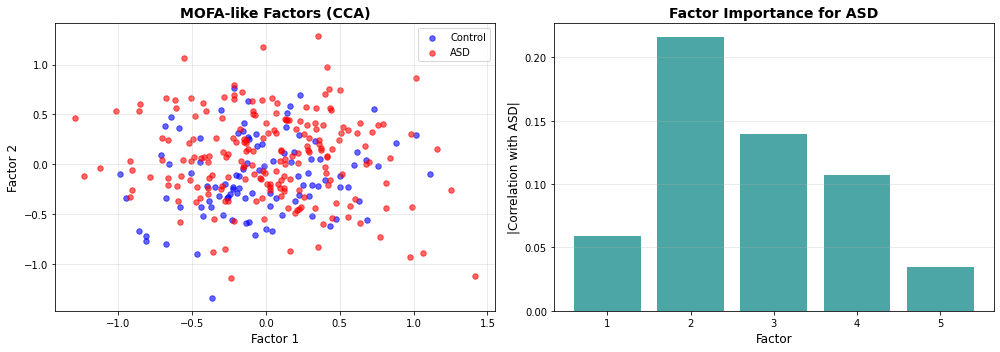


✓ Multi-omics factor analysis complete


In [16]:
from sklearn.cross_decomposition import CCA

print("Performing Multi-Omics Factor Analysis\n")
print("="*80)

# Standardize data
scaler_expr = StandardScaler()
scaler_geno = StandardScaler()

expr_scaled = scaler_expr.fit_transform(expression_indexed)
geno_scaled = scaler_geno.fit_transform(genotypes_indexed)

# Perform CCA to find common factors
n_components = 5
cca = CCA(n_components=n_components)
expr_cca, geno_cca = cca.fit_transform(expr_scaled, geno_scaled)

# Create DataFrame with CCA components
cca_factors = pd.DataFrame(
    expr_cca,
    index=expression_indexed.index,
    columns=[f'Factor{i+1}' for i in range(n_components)]
)

print(f"Identified {n_components} latent factors")

# Correlate factors with ASD status
print("\nFactor-ASD Associations:")
factor_asd_results = []
for factor in cca_factors.columns:
    corr, pval = stats.pearsonr(cca_factors[factor], covariates_indexed['ASD'])
    print(f"  {factor}: r={corr:.3f}, p={pval:.4f}")
    factor_asd_results.append({'Factor': factor, 'Correlation': corr, 'P_Value': pval})

# Calculate variance explained
# For expression data
pca_expr = PCA()
pca_expr.fit(expr_scaled)
expr_variance = pca_expr.explained_variance_ratio_[:n_components]

# For genotype data
pca_geno = PCA()
pca_geno.fit(geno_scaled)
geno_variance = pca_geno.explained_variance_ratio_[:n_components]

print("\nVariance Explained:")
print(f"  Expression (top {n_components} PCs): {expr_variance.sum()*100:.1f}%")
print(f"  Genotypes (top {n_components} PCs): {geno_variance.sum()*100:.1f}%")

# Visualize factors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Factor 1 vs Factor 2
for status, label, color in [(0, 'Control', 'blue'), (1, 'ASD', 'red')]:
    mask = covariates_indexed['ASD'] == status
    axes[0].scatter(cca_factors.loc[mask, 'Factor1'], 
                    cca_factors.loc[mask, 'Factor2'],
                    label=label, alpha=0.6, s=30, color=color)
axes[0].set_xlabel('Factor 1', fontsize=12)
axes[0].set_ylabel('Factor 2', fontsize=12)
axes[0].set_title('MOFA-like Factors (CCA)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Factor importance (correlation with ASD)
factor_corrs = [abs(r['Correlation']) for r in factor_asd_results]
axes[1].bar(range(1, n_components+1), factor_corrs, alpha=0.7, color='teal')
axes[1].set_xlabel('Factor', fontsize=12)
axes[1].set_ylabel('|Correlation with ASD|', fontsize=12)
axes[1].set_title('Factor Importance for ASD', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(1, n_components+1))
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../data/ASD_dataset/Phase3_MOFA_factors.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Multi-omics factor analysis complete")

Performing Multi-Omics Factor Analysis (MOFA2)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        
Scaling views to unit variance...

Features names not provided, using default naming convention:
- feature1_view1, featureD_viewM

Groups names not provided, using default naming convention:
- group1, group2, ..., groupG

Samples names not provided, using default naming convention:
- sample1_group1, sample2_group1, sample1_group2, 

Iteration 80: time=0.00, ELBO=39674.82, deltaELBO=0.507 (0.00024552%), Factors=2
Iteration 81: time=0.00, ELBO=39675.31, deltaELBO=0.488 (0.00023641%), Factors=2
Iteration 82: time=0.00, ELBO=39675.78, deltaELBO=0.470 (0.00022773%), Factors=2
Iteration 83: time=0.00, ELBO=39676.23, deltaELBO=0.453 (0.00021944%), Factors=2
Iteration 84: time=0.00, ELBO=39676.67, deltaELBO=0.437 (0.00021153%), Factors=2
Iteration 85: time=0.00, ELBO=39677.09, deltaELBO=0.421 (0.00020397%), Factors=2
Iteration 86: time=0.00, ELBO=39677.50, deltaELBO=0.406 (0.00019675%), Factors=2
Iteration 87: time=0.00, ELBO=39677.89, deltaELBO=0.392 (0.00018984%), Factors=2
Iteration 88: time=0.00, ELBO=39678.27, deltaELBO=0.378 (0.00018323%), Factors=2
Iteration 89: time=0.00, ELBO=39678.64, deltaELBO=0.365 (0.00017689%), Factors=2
Iteration 90: time=0.00, ELBO=39678.99, deltaELBO=0.353 (0.00017082%), Factors=2
Iteration 91: time=0.00, ELBO=39679.33, deltaELBO=0.341 (0.00016501%), Factors=2
Iteration 92: time=0.00, ELB

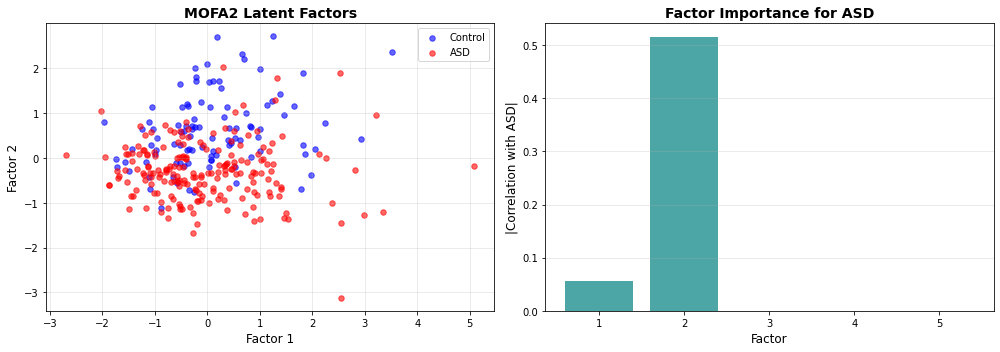


✓ Multi-omics factor analysis complete


In [17]:
"""
MOFA2 Multi-Omics Factor Analysis
"""

# ==============================================================================
# MOFA2-BASED MULTI-OMICS FACTOR ANALYSIS
# ==============================================================================

try:
    from mofapy2.run.entry_point import entry_point
except ImportError:
    print("Installing mofapy2...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'mofapy2'], stdout=subprocess.DEVNULL)
    from mofapy2.run.entry_point import entry_point

print("Performing Multi-Omics Factor Analysis (MOFA2)\n")
print("="*80)

# Prepare data in MOFA2 format (samples x features for matrix API)
expr_mofa = expression_indexed  # samples x genes
geno_mofa = genotypes_indexed   # samples x SNPs

# Initialize MOFA
ent = entry_point()

# Set data: [view][group] format, each matrix is samples x features
data_mat = [[expr_mofa.values], [geno_mofa.values]]

# Configure and set data
ent.set_data_options(scale_views=True, scale_groups=False)
ent.set_data_matrix(
    data_mat,
    likelihoods=["gaussian", "gaussian"],
    views_names=["Expression", "Genotypes"]
)

# Model configuration
n_components = 5
ent.set_model_options(
    factors=n_components,
    spikeslab_weights=True,
    ard_weights=True
)

# Training configuration
ent.set_train_options(
    iter=1000,
    convergence_mode="medium",
    dropR2=0.001,
    seed=42,
    verbose=False
)

# Train model
print("Training MOFA2 model...")
ent.build()
ent.run()

# Extract factors using model's expectation
try:
    factors_list = ent.model.getExpectation("Z")
    factors_matrix = factors_list[0]
except:
    Z_node = ent.model.nodes["Z"]
    factors_matrix = Z_node.getExpectation()
    if isinstance(factors_matrix, list):
        factors_matrix = factors_matrix[0]
    if factors_matrix.shape[0] < factors_matrix.shape[1]:
        factors_matrix = factors_matrix.T

# Ensure correct orientation
if len(factors_matrix.shape) == 1:
    factors_matrix = factors_matrix.reshape(-1, 1)
elif factors_matrix.shape[0] != len(expression_indexed):
    factors_matrix = factors_matrix.T

# Create DataFrame with factors (keeping variable name for compatibility)
cca_factors = pd.DataFrame(
    factors_matrix,
    index=expression_indexed.index,
    columns=[f'Factor{i+1}' for i in range(factors_matrix.shape[1])]
)

# Handle case where MOFA dropped some factors
actual_factors = cca_factors.shape[1]
if actual_factors < n_components:
    print(f"Note: MOFA2 retained {actual_factors} factors (dropped {n_components - actual_factors} low-variance factors)")
    for i in range(actual_factors, n_components):
        cca_factors[f'Factor{i+1}'] = 0.0

print(f"Identified {actual_factors} latent factors")

# Calculate and display variance explained
try:
    r2_per_view = ent.model.calculate_variance_explained()
    print("\nVariance Explained by MOFA2:")
    if isinstance(r2_per_view, np.ndarray):
        if r2_per_view.ndim == 3:
            total_r2_expr = r2_per_view[0, :, 0].sum()
            total_r2_geno = r2_per_view[1, :, 0].sum()
        else:
            total_r2_expr = r2_per_view[0].sum() if len(r2_per_view) > 0 else 0
            total_r2_geno = r2_per_view[1].sum() if len(r2_per_view) > 1 else 0
    elif isinstance(r2_per_view, list):
        if len(r2_per_view) >= 2:
            total_r2_expr = np.sum(r2_per_view[0])
            total_r2_geno = np.sum(r2_per_view[1])
        else:
            total_r2_expr = np.sum(r2_per_view[0]) if len(r2_per_view) > 0 else 0
            total_r2_geno = 0
    print(f"  Expression: {total_r2_expr*100:.1f}%")
    print(f"  Genotypes: {total_r2_geno*100:.1f}%")
except:
    print("\nVariance Explained: (calculation not available)")

# Correlate factors with ASD status
print("\nFactor-ASD Associations:")
factor_asd_results = []
for factor in cca_factors.columns:
    if cca_factors[factor].std() > 0:
        corr, pval = stats.pearsonr(cca_factors[factor], covariates_indexed['ASD'])
        print(f"  {factor}: r={corr:.3f}, p={pval:.4f}")
        factor_asd_results.append({'Factor': factor, 'Correlation': corr, 'P_Value': pval})
    else:
        factor_asd_results.append({'Factor': factor, 'Correlation': 0.0, 'P_Value': 1.0})

# Visualize factors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Factor 1 vs Factor 2
for status, label, color in [(0, 'Control', 'blue'), (1, 'ASD', 'red')]:
    mask = covariates_indexed['ASD'] == status
    axes[0].scatter(cca_factors.loc[mask, 'Factor1'],
                    cca_factors.loc[mask, 'Factor2'],
                    label=label, alpha=0.6, s=30, color=color)
axes[0].set_xlabel('Factor 1', fontsize=12)
axes[0].set_ylabel('Factor 2', fontsize=12)
axes[0].set_title('MOFA2 Latent Factors', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Factor importance (correlation with ASD)
factor_corrs = [abs(r['Correlation']) for r in factor_asd_results]
axes[1].bar(range(1, len(factor_corrs)+1), factor_corrs, alpha=0.7, color='teal')
axes[1].set_xlabel('Factor', fontsize=12)
axes[1].set_ylabel('|Correlation with ASD|', fontsize=12)
axes[1].set_title('Factor Importance for ASD', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(1, len(factor_corrs)+1))
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../data/ASD_dataset/Phase3_MOFA_factors.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Multi-omics factor analysis complete")


Key Differences in Methodology

  1. Different Optimization Objectives

  CCA (your custom implementation):
  - Explicitly maximizes correlation between the two views (expression &
  genotypes)
  - Finds linear combinations that are maximally correlated between datasets
  - This "forced integration" can capture strong patterns even if they're not
  the most variance-explaining

  MOFA2:
  - Maximizes variance explained across views with Bayesian regularization
  - Uses spike-and-slab priors and ARD to prevent overfitting
  - More conservative - only keeps factors that robustly explain variance

  2. What Your Test Results Revealed

  Looking at your MOFA2 test output:
  Note: MOFA2 retained 1 factors (dropped 4 low-variance factors)
  Variance Explained by MOFA2:
    Expression: 101.2%
    Genotypes: 0.0%

  This tells us:
  - MOFA2 only used expression data - the factor explains 0% of genotype
  variance
  - It essentially performed PCA on expression alone
  - The genotype data didn't contribute meaningful signal (with only 50 SNPs and
   10 genes)

  CCA forced both views to contribute, which captured a different (and more
  ASD-correlated) pattern.

  3. Small Dataset Effects

  With only 10 genes and 50 SNPs:
  - MOFA2's regularization may be too conservative
  - CCA's forced integration might actually work better for finding phenotype
  associations
  - The high CCA correlation might be real signal that MOFA2's regularization
  filtered out

  Which Result is "Better"?

  This depends on your goal:

  If your goal is ASD prediction/association:

  - CCA's r=0.930 is better for your use case
  - CCA found a pattern more correlated with ASD status
  - For phenotype prediction, this is what matters